In [1]:
import numpy as np
import jax
import jax.numpy as jnp
import equinox as eqx
import diffrax
from jaxtyping import Float

import dismech_jax as djx

from util_multiset_copy import *
from animate import animate

jax.config.update("jax_enable_x64", True)


In [2]:
class MLP(eqx.Module):
    layer1: eqx.nn.Linear
    layer2: eqx.nn.Linear

    def __init__(self, in_features: int, hidden_size: int, key: jax.Array):
        key1, key2 = jax.random.split(key)
        self.layer1 = eqx.nn.Linear(in_features, hidden_size, key=key1)
        self.layer2 = eqx.nn.Linear(hidden_size, 1, key=key2)

        self.layer1 = eqx.tree_at(
            lambda l: l.weight, self.layer1, self.layer1.weight * 1e-2
        )
        self.layer2 = eqx.tree_at(
            lambda l: l.weight, self.layer2, self.layer2.weight * 1e-2
        )

    def __call__(self, x: jax.Array) -> jax.Array:
        x = jax.nn.softplus(self.layer1(x))
        x = self.layer2(x)
        return jax.nn.softplus(x[0])


class Example(TripletModel):
    K: jax.Array  # = eqx.field(static=True)
    mlp: MLP

    def __init__(self, der_K: jax.Array, key: jax.Array):
        self.K = der_K
        self.mlp = MLP(5, 10, key)

    def __call__(self, del_strain: Float[jax.Array, "5"]) -> Float[jax.Array, ""]:
        stretching_energy = 0.5 * (self.K[0] * del_strain[0]**2 + self.K[0] * del_strain[1]**2)
        bending_energy = 0.5 * (self.K[1] * del_strain[3]**2)
        return stretching_energy + bending_energy



In [3]:
# train_datafile = "experiment_data/train_from_experiment.npz"
# valid_datafile = "experiment_data/train_from_experiment.npz"

train_datafile = "experiment_data/train.npz"
valid_datafile = "experiment_data/valid.npz"

init_K=jnp.array([0.1, 0.05])
validate_model(Example, der_K=init_K)

final_model, init_K, train_history, valid_history = train_model(Example, key=jax.random.PRNGKey(42), train_file=train_datafile, valid_file=valid_datafile, n_epochs=500, lr=1e-2, init_K=init_K )

print( "initial K: ", init_K)
print( "learned K: ", final_model.K)

Initial training loss: 1.00377e-04
K: [0.1  0.05]
grad K: [0.00019727 0.00164214]
loss finite? True
grad finite? True
Step 0    | LR: 1.000e-02  | Train: 1.00377e-04  | Valid: 7.75075e-05  | K: [0.09000051 0.04000006]
Step 10   | LR: 9.991e-03  | Train: 1.77264e-05  | Valid: 1.18646e-05  | K: [0.03254859 0.02252925]
Step 20   | LR: 9.965e-03  | Train: 4.34322e-06  | Valid: 4.40092e-06  | K: [0.03386067 0.01946673]
Step 30   | LR: 9.921e-03  | Train: 9.77305e-07  | Valid: 1.15455e-06  | K: [0.03169072 0.01728263]
Step 40   | LR: 9.859e-03  | Train: 1.33328e-06  | Valid: 1.06136e-06  | K: [0.02824765 0.01623914]
Step 50   | LR: 9.781e-03  | Train: 1.11055e-06  | Valid: 1.07737e-06  | K: [0.03084618 0.01631349]
Step 60   | LR: 9.685e-03  | Train: 9.65855e-07  | Valid: 1.00069e-06  | K: [0.03073763 0.01644398]
Step 70   | LR: 9.573e-03  | Train: 9.55017e-07  | Valid: 9.33686e-07  | K: [0.02982143 0.01645039]
Step 80   | LR: 9.446e-03  | Train: 9.59131e-07  | Valid: 9.55552e-07  | K: [0.029

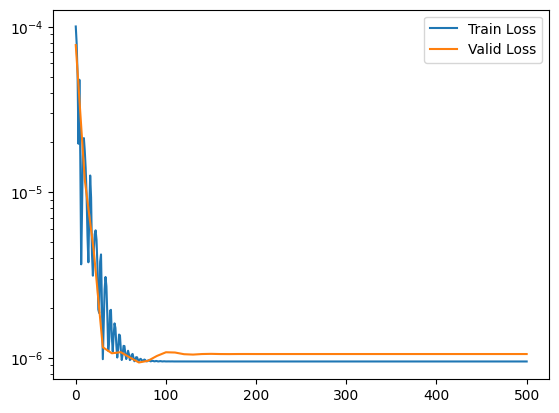

In [4]:
import matplotlib.pyplot as plt
train_np = np.asarray(train_history, dtype=float).reshape(-1)
valid_np = np.asarray(valid_history, dtype=float).reshape(-1)

idx_valid = np.where(valid_np != -1)[0]

plt.plot(np.arange(train_np.size), train_np, label="Train Loss")
plt.plot(idx_valid, valid_np[idx_valid], label="Valid Loss")
plt.yscale("log")
plt.legend()
plt.show()

In [5]:
from util_multiset_copy import TestCase

train = TestCase.from_npz(train_datafile)
valid = TestCase.from_npz(valid_datafile)


print("train.qs finite:", jnp.all(jnp.isfinite(train.qs)))
print("train.xb finite:", jnp.all(jnp.isfinite(train.xb)))
print("train.lambdas finite:", True if train.lambdas is None else jnp.all(jnp.isfinite(train.lambdas)))

print("valid.qs finite:", jnp.all(jnp.isfinite(valid.qs)))
print("valid.xb finite:", jnp.all(jnp.isfinite(valid.xb)))
print("valid.lambdas finite:", True if valid.lambdas is None else jnp.all(jnp.isfinite(valid.lambdas)))


train.qs finite: True
train.xb finite: True
train.lambdas finite: True
valid.qs finite: True
valid.xb finite: True
valid.lambdas finite: True


In [6]:
# base, aux, der = get_base_rod()
# train = TestCase.from_npz(train_datafile)

# model = Example(der_K=jnp.array([0.1, 0.05]), key=jax.random.PRNGKey(42))
# debug_dataset_loss(model, base, aux, train)

In [7]:
def make_bc_from_testcase(dataset, i=None):
    lambdas = dataset.lambdas if dataset.lambdas is not None else jnp.linspace(0.0, 1.0, dataset.qs.shape[1])

    if i is None:
        idx_b = dataset.idx_b
        xb = dataset.xb
    else:
        idx_b = dataset.idx_b if dataset.idx_b.ndim == 1 else dataset.idx_b[i]
        xb = dataset.xb[i]

    print("xb.shape", xb.shape)
    return djx.BatchedDirectBC(
        idx_b=idx_b,
        xb=xb,
        lambdas=lambdas,
    )

In [8]:
print("valid.xb.shape", valid.xb.shape)
lambdas = valid.lambdas if valid.lambdas is not None else jnp.linspace(0.0, 1.0, valid.qs.shape[1])
base, aux, _ = get_base_rod()
bc = make_bc_from_testcase(valid)
rod = base.with_bc(bc)
pred = rod.solve(final_model, lambdas, aux, max_dlambda=5e-3, iters=5, ls_steps=10)
print("pred.shape", pred.shape)
print("valid.qs.shape", valid.qs.shape)
print("train.qs.shape", train.qs.shape)
# animate(pred)

valid.xb.shape (2, 10, 8)
xb.shape (2, 10, 8)
pred.shape (2, 10, 11)
valid.qs.shape (2, 10, 11)
train.qs.shape (2, 10, 11)


In [9]:
# animate(valid.qs)

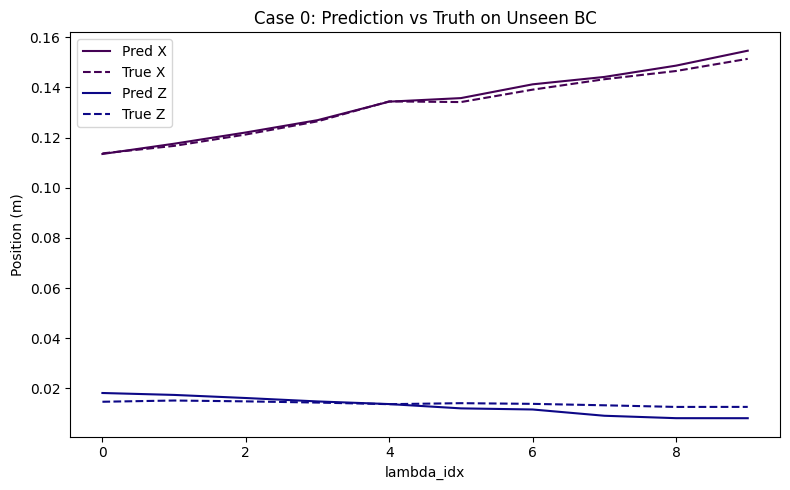

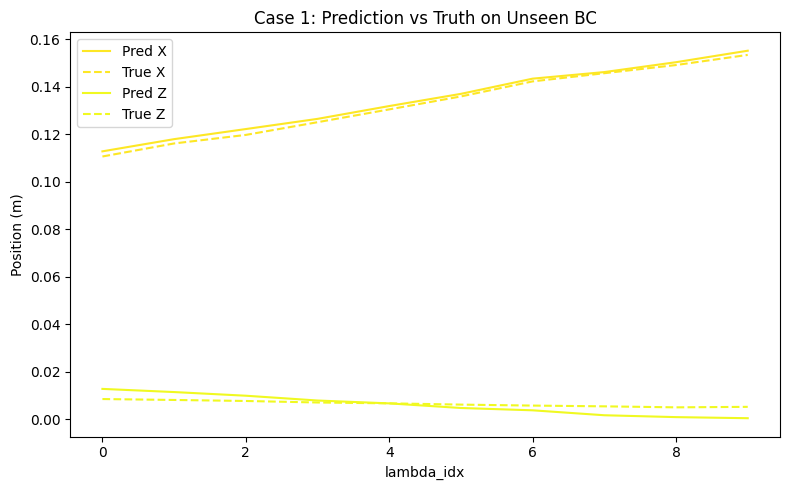

In [10]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import jax.numpy as jnp

n_cases = pred.shape[0]

# one colormap per coordinate
colors_x = cm.viridis(jnp.linspace(0, 1, n_cases))
colors_z = cm.plasma(jnp.linspace(0, 1, n_cases))

for i in range(n_cases):
    cx = colors_x[i]
    cz = colors_z[i]

    fig, ax = plt.subplots(figsize=(8, 5))

    # X coordinate
    ax.plot(pred[i, :, 4], color=cx, linestyle='-', label='Pred X')
    ax.plot(valid.qs[i, :, 4], color=cx, linestyle='--', label='True X')

    # Z coordinate
    ax.plot(pred[i, :, 6], color=cz, linestyle='-', label='Pred Z')
    ax.plot(valid.qs[i, :, 6], color=cz, linestyle='--', label='True Z')

    ax.set_title(f"Case {i}: Prediction vs Truth on Unseen BC")
    ax.set_xlabel("lambda_idx")
    ax.set_ylabel("Position (m)")
    ax.legend()
    fig.tight_layout()
    plt.show()

In [11]:
print("Training BC:")
print("init: ", train.qs[0, 8:11])
print("final: ", train.qs[-1, 8:11])

print("Validation BC:")
print("init: ", valid.qs[0, 8:11])
print("final: ", valid.qs[-1, 8:11])

Training BC:
init:  [[0.         0.         0.         0.         0.11300349 0.
  0.01657482 0.         0.23382102 0.         0.13500646]
 [0.         0.         0.         0.         0.10997066 0.
  0.01648045 0.         0.22677252 0.         0.13321703]]
final:  [[0.         0.         0.         0.         0.11143794 0.
  0.01026583 0.         0.23206285 0.         0.11900306]
 [0.         0.         0.         0.         0.10697546 0.
  0.01032906 0.         0.22445548 0.         0.11741954]]
Validation BC:
init:  [[0.         0.         0.         0.         0.14655865 0.
  0.01259217 0.         0.29649265 0.         0.12744382]
 [0.         0.         0.         0.         0.15141125 0.
  0.01260447 0.         0.30737344 0.         0.13081271]]
final:  [[0.         0.         0.         0.         0.14919935 0.
  0.00509007 0.         0.30000829 0.         0.11267491]
 [0.         0.         0.         0.         0.15346497 0.
  0.00529648 0.         0.30894686 0.         0.11458

In [12]:
print("initial position of the middle node in the training data: ", train.qs[0, 4:7])
print("final position of the middle node in the training data: ", train.qs[-1, 4:7])

initial position of the middle node in the training data:  [[0.         0.         0.         0.         0.13277641 0.
  0.01725533 0.         0.26653386 0.         0.13789818]
 [0.         0.         0.         0.         0.12705972 0.
  0.01727204 0.         0.25443739 0.         0.13331234]
 [0.         0.         0.         0.         0.12212673 0.
  0.01723858 0.         0.24612272 0.         0.13362513]]
final position of the middle node in the training data:  [[0.         0.         0.         0.         0.1312469  0.
  0.01043344 0.         0.26560806 0.         0.12132298]
 [0.         0.         0.         0.         0.12613359 0.
  0.01047439 0.         0.25672117 0.         0.12172881]
 [0.         0.         0.         0.         0.12149112 0.
  0.010437   0.         0.24942622 0.         0.12254084]]


In [13]:
print("initial position of the middle node in the validation data: ", valid.qs[0, 4:7])
print("final position of the middle node in the validation data: ", valid.qs[-1, 4:7])

initial position of the middle node in the validation data:  [[0.         0.         0.         0.         0.13444641 0.
  0.01368943 0.         0.27034087 0.         0.13141174]
 [0.         0.         0.         0.         0.13416888 0.
  0.01408874 0.         0.27294775 0.         0.12834982]
 [0.         0.         0.         0.         0.13912665 0.
  0.01381549 0.         0.28279979 0.         0.13075516]]
final position of the middle node in the validation data:  [[0.         0.         0.         0.         0.13052639 0.
  0.00677359 0.         0.2663429  0.         0.11360569]
 [0.         0.         0.         0.         0.13598007 0.
  0.00624168 0.         0.27560766 0.         0.11266652]
 [0.         0.         0.         0.         0.1423159  0.
  0.00583113 0.         0.28722089 0.         0.11468523]]


In [14]:
print("initial position of the middle node in the prediction: ", pred[0, 4:7])
print("final position of the middle node in the prediction: ", pred[-1, 4:7])

initial position of the middle node in the prediction:  [[0.         0.         0.         0.         0.1343387  0.
  0.0137275  0.         0.27034087 0.         0.13141174]
 [0.         0.         0.         0.         0.13575322 0.
  0.01201679 0.         0.27294775 0.         0.12834982]
 [0.         0.         0.         0.         0.14124625 0.
  0.01157023 0.         0.28279979 0.         0.13075516]]
final position of the middle node in the prediction:  [[0.         0.         0.         0.         0.13193162 0.
  0.00675671 0.         0.2663429  0.         0.11360569]
 [0.         0.         0.         0.         0.13706721 0.
  0.00481686 0.         0.27560766 0.         0.11266652]
 [0.         0.         0.         0.         0.14346756 0.
  0.00383861 0.         0.28722089 0.         0.11468523]]
